# Download ESRI Landcover with Mercator Tiles

This script downloads and processes land use/land cover (LULC) raster data from the Planetary Computer STAC API for tiles that intersect a specified Area of Interest (AOI). The processing is done in parallel using ProcessPoolExecutor to speed up both querying and downloading of raster data.

1. Configuration Variables

    File Paths: Defines paths for the shapefile (AOI), output CSV, and directory for saving raster files.
    Processing Parameters:
        zoom = 7 → Defines the resolution of tiles.
        year = 2023 → Filters the dataset for the specified year.
        num_workers_query = 70 → Parallel workers for querying STAC API.
        num_workers_download = 40 → Parallel workers for downloading rasters.
        overwrite_existing_files = True → Controls whether to re-download files.
        buffer_km = 30 → Expands the bounding box to ensure complete coverage.

2. Load and Process the AOI

    If aoi_colorado is True, it uses a hardcoded Colorado bounding box.
    Otherwise, it loads the shapefile containing the study area.
    Converts the AOI to EPSG:4326 (latitude/longitude).
    Expands the AOI by 1 km for better coverage.

3. Determine Tiles that Intersect the AOI

    Uses mercantile.tiles() to generate map tiles at zoom level 7.
    Filters tiles that intersect the AOI.
    Each tile is identified by a quadkey.

4. Query the Planetary Computer STAC API

    Connects to the Planetary Computer STAC API to find relevant satellite data.
    Buffers each tile by 30 km to ensure full tile coverage.
    Queries the STAC catalog for available LULC images from the "io-lulc-annual-v02" collection.
    Stores metadata, including:
        Tile ID (zoom-x-y).
        Bounding box (buffered).
        STAC item details.

5. Parallel Processing for STAC Queries

    Uses ProcessPoolExecutor to query tiles in parallel (70 workers).
    Stores the query results in a Pandas DataFrame.
    Saves the metadata to a CSV file.

6. Download and Merge Raster Data

    For each tile:
        Finds matching STAC items.
        Downloads raster files.
        Stacks and mosaics raster data using stackstac.
        Saves the merged raster as a GeoTIFF file (.tif).
    Uses rasterio to write the final processed raster.
    Handles missing tiles, skips duplicates (if overwrite_existing_files is False).

7. Parallel Downloading of Rasters

    Uses ProcessPoolExecutor (40 workers) to download and merge raster tiles in parallel.
    Saves processed GeoTIFF files to a local directory.
    Handles errors for missing or failed downloads.



In [2]:
import concurrent.futures
import geopandas as gpd
import mercantile
import numpy as np
import pandas as pd
import planetary_computer
import pystac
import pystac_client
from shapely import geometry
from tqdm import tqdm
import os
import rasterio
import stackstac
import xarray as xr
from rasterio.enums import Resampling

# File paths setup
shapefile_path = "/home/shares/wwri-wildfire/data/multi-domain-data/boundary-layers/processed/admin-boundary-layers/wwri_study_area_admin_0.shp"  # Path to your shapefile

# Edited: Use a generic relative path for the CSV output
output_csv = "stac_items_overlapping_tiles.csv"

local_dir = "/home/shares/wwri-wildfire/data/multi-domain-data/esri-land-use-land-cover-10m"  # Directory to save the downloaded raster tiles

# Setup
aoi_colorado = False  # Set to True to use Colorado bounding box, False to use shapefile AOI
num_workers_query = 70  # Adjust this number based on your available cores for querying
num_workers_download = 40  # Number of workers for downloading tiles
zoom = 7  # Zoom level for the Mercantile tiles
year = 2023  # Year for the data
overwrite_existing_files = False  # Set to True to overwrite existing files, False to skip them
buffer_km = 30  # Buffer size in kilometers

# Step 1 - Define our area of interest (AOI)
if aoi_colorado:
    print("Using Colorado bounding box as AOI...")
    colorado_bbox = [-109.045223, 36.993076, -102.041524, 41.003444]  # Bounding box for Colorado
    aoi_shape = geometry.box(*colorado_bbox)
    aoi_gdf = gpd.GeoDataFrame(geometry=[aoi_shape], crs="EPSG:4326")
else:
    print("Loading the shapefile...")
    aoi_gdf = gpd.read_file(shapefile_path)

# Ensure the AOI is in EPSG:4326
if aoi_gdf.crs != "EPSG:4326":
    aoi_gdf = aoi_gdf.to_crs("EPSG:4326")

# Assuming the shapefile has only one polygon, otherwise select the specific polygon
aoi_shape = aoi_gdf.geometry.iloc[0]

# Apply a 1 km buffer around the AOI (approx. 0.01 degrees at the equator)
aoi_shape = aoi_shape.buffer(0.01)

# Step 2 - Determine which tiles intersect our AOI
def get_intersecting_tiles(polygon, zoom):
    tiles = mercantile.tiles(*polygon.bounds, zoom)
    intersecting_tiles = [
        tile for tile in tiles
        if geometry.box(*mercantile.bounds(tile)).intersects(polygon)
    ]
    return intersecting_tiles

tiles = get_intersecting_tiles(aoi_shape, zoom)

# Step 4 - Access the Planetary Computer STAC API
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Step 5 - Query STAC items and create a DataFrame
def get_stac_items_for_tile(tile):
    bbox = mercantile.bounds(tile)
    
    # Calculate the buffer in degrees (approx. 111 km per degree at the equator)
    buffer_degrees = buffer_km / 111
    
    # Create buffered bounding box and clip to valid range
    buffered_bbox = [
        max(-180, min(180, bbox.west - buffer_degrees)),
        max(-90, min(90, bbox.south - buffer_degrees)),
        max(-180, min(180, bbox.east + buffer_degrees)),
        max(-90, min(90, bbox.north + buffer_degrees))
    ]
    
    search = catalog.search(
        collections=["io-lulc-annual-v02"],
        bbox=buffered_bbox,
        datetime=f"{year}-01-01/{year}-12-31"
    )
    items = list(search.get_items())
    results = []
    for item in items:
        item_metadata = {
            'tile_id': f"{tile.z}-{tile.x}-{tile.y}",
            'buffered_tile_bbox': buffered_bbox,
            'quadkey': mercantile.quadkey(tile),
            'stac_item': item.to_dict(),
        }
        results.append(item_metadata)
    return results

def query_stac_items_parallel(tiles, num_workers):
    print(f"Using {num_workers} workers for parallel querying...")
    all_results = []
    with concurrent.futures.ProcessPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(get_stac_items_for_tile, tile): tile for tile in tiles}
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(tiles)):
            try:
                result = future.result()
                all_results.extend(result)
            except Exception as e:
                print(f"Error querying tile: {e}")
    print("All tiles have been queried.")
    return all_results

# Perform the parallel querying
all_stac_items = query_stac_items_parallel(tiles, num_workers_query)

# Create a DataFrame from the results
df = pd.DataFrame(all_stac_items)

# Save the DataFrame to a CSV file using the generic relative path
df.to_csv(output_csv, index=False)
print(f"DataFrame saved to {output_csv}")

# Step 6 - Download raster data for each tile
def download_and_merge_tile_assets(tile, stac_items):
    # Retrieve the buffered bounding box for the tile
    items = [item for item in stac_items if item['tile_id'] == f"{tile.z}-{tile.x}-{tile.y}"]
    if not items:
        print(f"No items found for tile {mercantile.quadkey(tile)}")
        return
    
    buffered_bbox = items[0]['buffered_tile_bbox']  # Assuming all items have the same buffered_bbox
    quadkey = mercantile.quadkey(tile)
    local_path = os.path.join(local_dir, f"{quadkey}.tif")
    
    if not overwrite_existing_files and os.path.exists(local_path):
        print(f"Skipping existing file: {local_path}")
        return
    
    # Print which tile and STAC items are being processed
    print(f"Processing tile {quadkey} with {len(items)} STAC items")
    
    # Get the EPSG code from the first item
    common_epsg = items[0]['stac_item']['properties']['proj:epsg']
    print(f"Using common EPSG: {common_epsg} for tile {quadkey}")
    
    try:
        # Stack and merge rasters using stackstac
        stack = stackstac.stack(
            [pystac.Item.from_dict(item['stac_item']) for item in items],
            bounds_latlon=buffered_bbox,  # Use the buffered bounding box
            epsg=common_epsg,
            dtype='uint8',
            fill_value=255,
            resampling=Resampling.nearest
        )
        
        # Mosaic to compress into one band
        merged_raster = stackstac.mosaic(stack, dim='time', nodata=255).compute()
        merged_raster = merged_raster.squeeze()  # Ensure it's a single band
        print(f"Merged raster shape: {merged_raster.shape}")
        
        # Ensure the local directory exists
        os.makedirs(local_dir, exist_ok=True)
        
        # Save the merged raster to a file
        height, width = merged_raster.shape[-2], merged_raster.shape[-1]
        with rasterio.open(
            local_path,
            'w',
            driver='GTiff',
            height=height,
            width=width,
            count=1,  # Single-band raster
            dtype=merged_raster.dtype,
            crs=stack.attrs['crs'],
            transform=stack.attrs['transform'],
        ) as dst:
            dst.write(merged_raster, 1)
        print(f"Downloaded and merged {local_path}")
    except Exception as e:
        print(f"Error downloading or merging tile {quadkey} with STAC items {[item['stac_item']['id'] for item in items]}: {e}")

def download_tiles_parallel(tiles, stac_items, num_workers):
    print(f"Using {num_workers} workers for parallel downloading and merging...")
    with concurrent.futures.ProcessPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(download_and_merge_tile_assets, tile, stac_items): tile for tile in tiles}
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(tiles)):
            try:
                future.result()
            except Exception as e:
                print(f"Error downloading or merging tile: {e}")
    print("All tiles have been downloaded and merged.")

# Finally, download and merge rasters for all tiles
download_tiles_parallel(tiles, all_stac_items, num_workers_download)


Loading the shapefile...
Using 70 workers for parallel querying...


  0%|          | 0/282 [00:00<?, ?it/s]/home/cbroderick/brazil_env/lib/python3.10/site-packages/pystac_client/item_search.py:834: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
/home/cbroderick/brazil_env/lib/python3.10/site-packages/pystac_client/item_search.py:834: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
/home/cbroderick/brazil_env/lib/python3.10/site-packages/pystac_client/item_search.py:834: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
/home/cbroderick/brazil_env/lib/python3.10/site-packages/pystac_client/item_search.py:834: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
/home/cbroderick/brazil_env/lib/python3.10/site-packages/pystac_client/item_search.py:834: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
/home/cbroderick/brazil_env/lib/python3.10/site-packages/pystac_client/item_search.py:834: FutureWarning: get_i

All tiles have been queried.
DataFrame saved to stac_items_overlapping_tiles.csv
Using 40 workers for parallel downloading and merging...


  0%|          | 0/282 [00:00<?, ?it/s]

Skipping existing file: /home/shares/wwri-wildfire/data/multi-domain-data/esri-land-use-land-cover-10m/0202020.tif


...

Skipping existing file: /home/shares/wwri-wildfire/data/multi-domain-data/esri-land-use-land-cover-10m/0231031.tif
Skipping existing file: /home/shares/wwri-wildfire/data/multi-domain-data/esri-land-use-land-cover-10m/0231033.tif


 99%|█████████▉| 279/282 [00:26<00:00, 23.87it/s]

Error downloading or merging tile 0200112 with STAC items ['60W-2023', '04W-2023', '04V-2023', '03W-2023', '03V-2023', '01W-2023', '60W-2022', '04W-2022', '04V-2022', '03W-2022', '03V-2022', '01W-2022']: can_cast() does not support Python ints, floats, and complex because the result used to depend on the value.
This change was part of adopting NEP 50, we may explicitly allow them again in the future.


100%|██████████| 282/282 [00:42<00:00,  6.58it/s]

All tiles have been downloaded and merged.


# Testing, Validating, and Visualizing Landcover and Polygon files

Santa Barbara bounding box: [-120, 34.455, -119.6, 34.48]
Quadkey for the tile containing the center of Santa Barbara: 0230121
Looking for polygon file: /home/cbroderick/exploration/defensible-space/building_defensible_space_polygons/zoom_7_buffer_30m/0230121.featherLooking for polygon file: /home/cbroderick/exploration/defensible-space/building_defensible_space_polygons/zoom_7_original/0230121.featherLooking for polygon file: /home/cbroderick/exploration/defensible-space/building_defensible_space_polygons/zoom_7_buffer_10m/0230121.feather


Polygon file found. Reading data...Polygon file found. Reading data...
Polygon file found. Reading data...

Number of polygons read: 1097527
Number of polygons in subset: 2652
Number of polygons read: 1097527
Number of polygons read: 1097527
Number of polygons in subset: 2770
Number of polygons in subset: 2685
Reading raster data...
Raster CRS: EPSG:32611


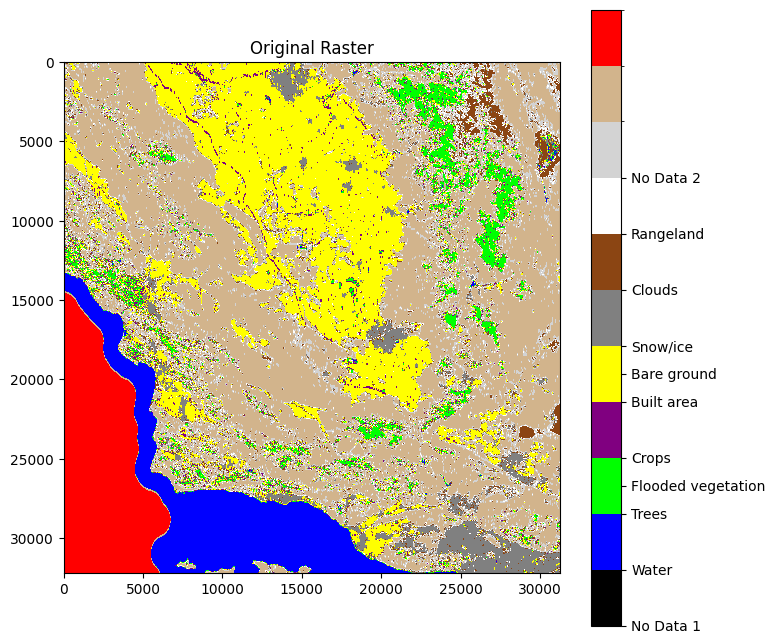

Original raster cell classification counts:
Water: 77614227
Trees: 62414778
Flooded vegetation: 153442
Crops: 183430249
Built area: 54577653
Bare ground: 16107833
Snow/ice: 528306
Clouds: 102
Rangeland: 536036638
No Data 2: 74843224


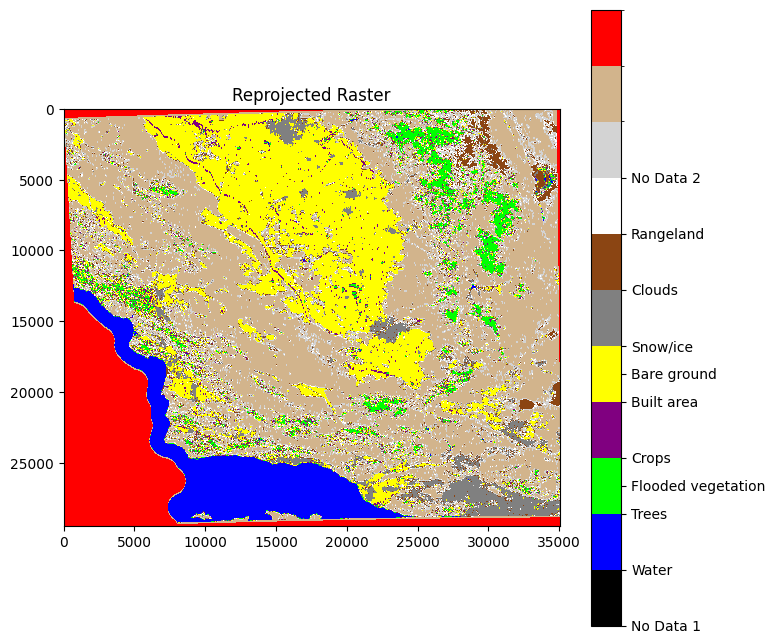

Reprojected raster cell classification counts:
Water: 74803257
Trees: 61098834
Flooded vegetation: 150093
Crops: 180106044
Built area: 53066945
Bare ground: 15863431
Snow/ice: 524224
Clouds: 100
Rangeland: 523663181
No Data 2: 123087461


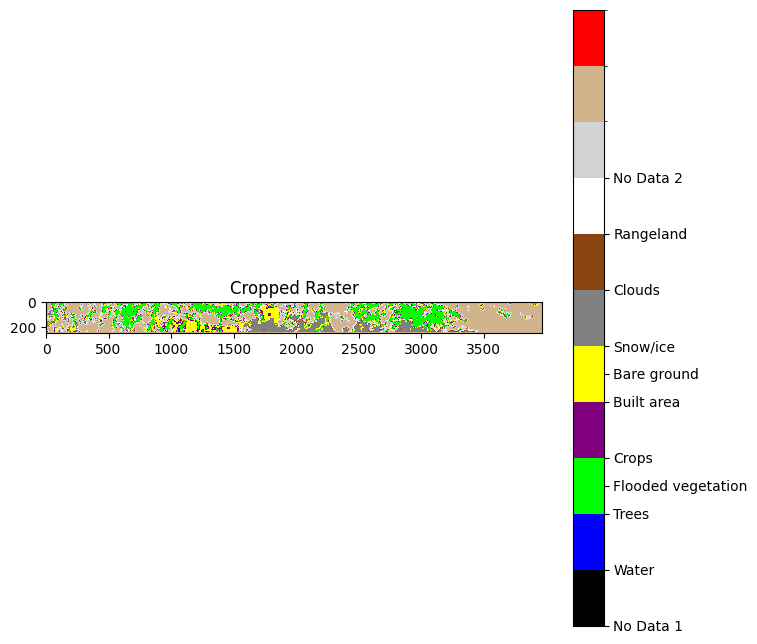

Cropped raster cell classification counts:
Water: 1843
Trees: 228583
Crops: 63615
Built area: 91818
Bare ground: 23535
Rangeland: 570455
No Data 2: 7934


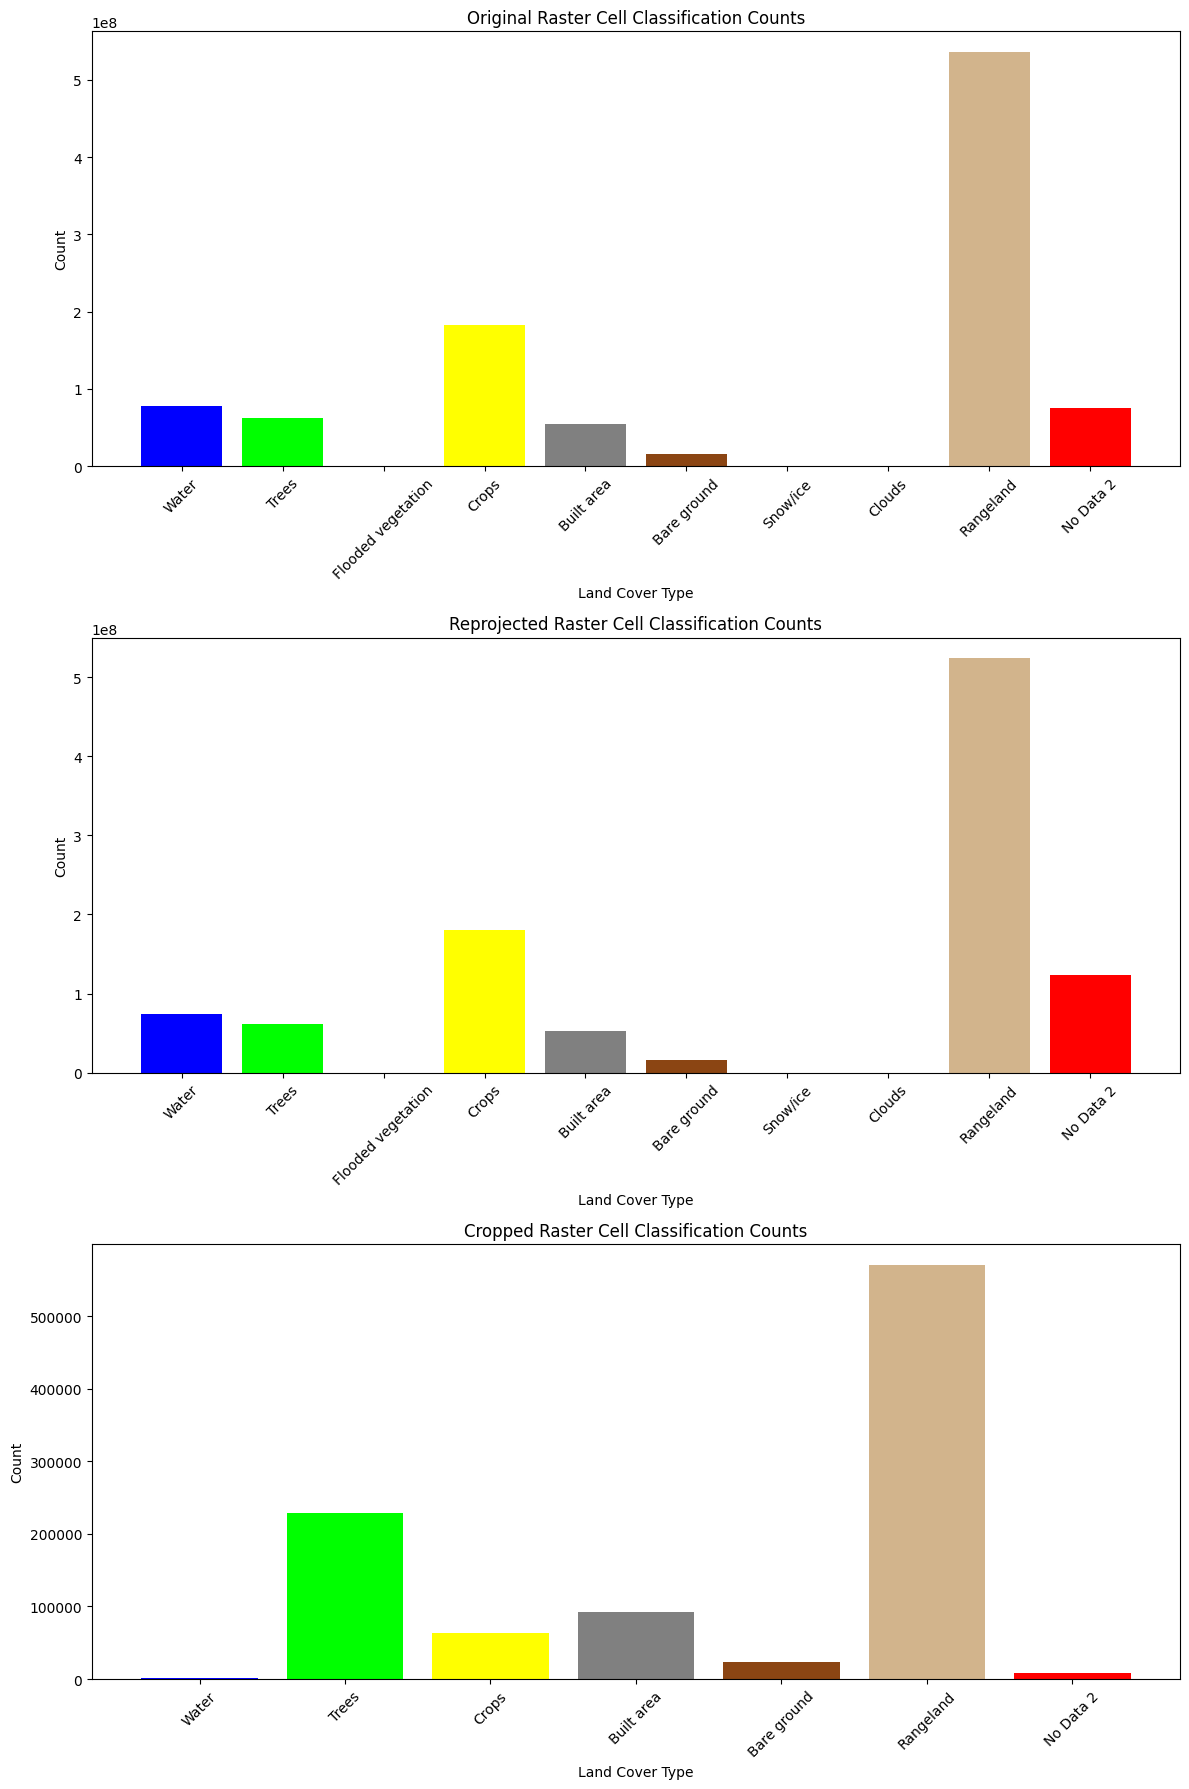

Creating map...
Combined map saved as: /home/cbroderick/exploration/defensible-space/output_maps/santa_barbara_combined_map.html


In [4]:
import os
import geopandas as gpd
import pyarrow.feather as feather
import folium
from shapely import wkb
import mercantile
import rasterio
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import box
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
import imageio
import branca
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# Set input and output directories
tile_dir = "/home/cbroderick/exploration/defensible-space/land_cover_tiles"
polygon_dir_30m = "/home/cbroderick/exploration/defensible-space/building_defensible_space_polygons/zoom_7_buffer_30m"
polygon_dir_original = "/home/cbroderick/exploration/defensible-space/building_defensible_space_polygons/zoom_7_original"
polygon_dir_10m = "/home/cbroderick/exploration/defensible-space/building_defensible_space_polygons/zoom_7_buffer_10m"
output_dir = "/home/cbroderick/exploration/defensible-space/output_maps"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Bounding box for all of Santa Barbara city (approximate)
santa_barbara_bbox = [-120, 34.455, -119.6, 34.48]
print(f"Santa Barbara bounding box: {santa_barbara_bbox}")

# Find the mercator tile associated with the center of this bounding box
center_lon = (santa_barbara_bbox[0] + santa_barbara_bbox[2]) / 2
center_lat = (santa_barbara_bbox[1] + santa_barbara_bbox[3]) / 2
tile = mercantile.tile(center_lon, center_lat, zoom=7)

# Get the quadkey for this tile
quadkey = mercantile.quadkey(tile)
print(f"Quadkey for the tile containing the center of Santa Barbara: {quadkey}")

# Function to read and process polygon data
def read_and_process_polygons(args):
    polygon_dir, bbox, geom_col, quadkey = args
    polygon_file = os.path.join(polygon_dir, f"{quadkey}.feather")
    print(f"Looking for polygon file: {polygon_file}")

    if not os.path.exists(polygon_file):
        print(f"Error: Polygon file {polygon_file} not found.")
        return None

    print("Polygon file found. Reading data...")

    # Read the polygon feather file
    polygon_df = feather.read_feather(polygon_file)
    print(f"Number of polygons read: {len(polygon_df)}")

    # Convert WKB to geometries
    polygon_df[geom_col] = polygon_df[geom_col].apply(wkb.loads)

    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(polygon_df, geometry=geom_col, crs="EPSG:4326")

    # Subset polygons by bounding box
    subset_gdf = gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
    print(f"Number of polygons in subset: {len(subset_gdf)}")

    return subset_gdf

# Process polygons from all three datasets in parallel
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = [
        executor.submit(read_and_process_polygons, (polygon_dir_30m, santa_barbara_bbox, 'geometry_30m', quadkey)),
        executor.submit(read_and_process_polygons, (polygon_dir_original, santa_barbara_bbox, 'geometry', quadkey)),
        executor.submit(read_and_process_polygons, (polygon_dir_10m, santa_barbara_bbox, 'geometry_10m', quadkey))
    ]
    subset_gdf_30m, subset_gdf_original, subset_gdf_10m = [future.result() for future in futures]

print("Reading raster data...")

# Define the color key, including different colors for No Data
color_key = {
    0: '#000000',  # No Data 1
    1: '#0000FF',  # Water
    2: '#00FF00',  # Trees
    4: '#800080',  # Flooded vegetation
    5: '#FFFF00',  # Crops
    7: '#808080',  # Built area
    8: '#8B4513',  # Bare ground
    9: '#FFFFFF',  # Snow/ice
    10: '#D3D3D3',  # Clouds
    11: '#D2B48C',  # Rangeland
    255: '#FF0000'  # No Data 2 (different color from 0)
}

classification_names = {0: 'No Data 1', 1: 'Water', 2: 'Trees', 4: 'Flooded vegetation', 5: 'Crops',
                        7: 'Built area', 8: 'Bare ground', 9: 'Snow/ice', 10: 'Clouds', 11: 'Rangeland',
                        255: 'No Data 2'}

# Define the discrete colormap and normalization
cmap = ListedColormap([color_key[key] for key in sorted(color_key.keys())])
norm = BoundaryNorm(sorted(color_key.keys()) + [max(color_key.keys()) + 1], cmap.N)

# Read the raster file and check its CRS
raster_path = os.path.join(tile_dir, '0230121.tif')
with rasterio.open(raster_path) as src:
    original_raster_data = src.read(1)
    raster_crs = src.crs
    print(f"Raster CRS: {raster_crs}")

    # Ensure the raster CRS is known
    if raster_crs is None:
        raise ValueError("The raster does not have a CRS.")

# Plot the original raster as categorical data
plt.figure(figsize=(8, 8))
plt.imshow(original_raster_data, cmap=cmap, norm=norm)
plt.title("Original Raster")
cbar = plt.colorbar(boundaries=np.arange(len(color_key)+1)-0.5, ticks=np.arange(len(color_key)))
cbar.ax.set_yticklabels([f"{classification_names[key]}" for key in sorted(color_key.keys())])
plt.show()

# Count the number of each cell classification in the original raster
unique, counts = np.unique(original_raster_data, return_counts=True)
original_classification_counts = dict(zip(unique, counts))

print("Original raster cell classification counts:")
for classification, count in original_classification_counts.items():
    classification_name = classification_names[classification]
    print(f"{classification_name}: {count}")

# Reproject the entire raster to WGS84 (EPSG:4326)
dst_crs = 'EPSG:4326'
reprojected_raster_path = os.path.join(tile_dir, 'reprojected_raster.tif')
with rasterio.open(raster_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height,
        'dtype': 'int32',
        'nodata': 255  # Specify No Data value
    })

    reprojected_raster_data = np.empty((height, width), dtype=np.int32)
    with rasterio.open(reprojected_raster_path, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=reprojected_raster_data,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest,
                src_nodata=255,  # Handle No Data values
                dst_nodata=255)
            dst.write(reprojected_raster_data, i)

# Plot the reprojected raster as categorical data
with rasterio.open(reprojected_raster_path) as src:
    reprojected_raster_data = src.read(1)

plt.figure(figsize=(8, 8))
plt.imshow(reprojected_raster_data, cmap=cmap, norm=norm)
plt.title("Reprojected Raster")
cbar = plt.colorbar(boundaries=np.arange(len(color_key)+1)-0.5, ticks=np.arange(len(color_key)))
cbar.ax.set_yticklabels([f"{classification_names[key]}" for key in sorted(color_key.keys())])

# Plot the bounding box for the crop on the reprojected raster
santa_barbara_geom = gpd.GeoDataFrame({'geometry': [box(*santa_barbara_bbox)]}, crs='EPSG:4326')
santa_barbara_geom.to_crs(dst_crs, inplace=True)
santa_barbara_bounds = santa_barbara_geom.geometry.iloc[0].bounds
rect = plt.Rectangle((santa_barbara_bounds[0], santa_barbara_bounds[1]), 
                     santa_barbara_bounds[2] - santa_barbara_bounds[0], 
                     santa_barbara_bounds[3] - santa_barbara_bounds[1], 
                     linewidth=2, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect)
plt.show()

# Count the number of each cell classification in the reprojected raster
unique, counts = np.unique(reprojected_raster_data, return_counts=True)
reprojected_classification_counts = dict(zip(unique, counts))

print("Reprojected raster cell classification counts:")
for classification, count in reprojected_classification_counts.items():
    classification_name = classification_names[classification]
    print(f"{classification_name}: {count}")

# Crop the reprojected raster using the WGS84 bounding box
santa_barbara_geom = gpd.GeoDataFrame({'geometry': [box(*santa_barbara_bbox)]}, crs='EPSG:4326')

with rasterio.open(reprojected_raster_path) as src:
    out_image, out_transform = mask(src, santa_barbara_geom.geometry, crop=True, nodata=255)
    out_meta = src.meta.copy()

out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    'dtype': 'int32',
    'nodata': 255
})

# Save the cropped raster to a new file
cropped_raster_path = os.path.join(tile_dir, 'cropped_raster.tif')
with rasterio.open(cropped_raster_path, "w", **out_meta) as dest:
    dest.write(out_image)

# Plot the cropped raster as categorical data
cropped_raster_data = out_image[0]

plt.figure(figsize=(8, 8))
plt.imshow(cropped_raster_data, cmap=cmap, norm=norm)
plt.title("Cropped Raster")
cbar = plt.colorbar(boundaries=np.arange(len(color_key)+1)-0.5, ticks=np.arange(len(color_key)))
cbar.ax.set_yticklabels([f"{classification_names[key]}" for key in sorted(color_key.keys())])
plt.show()

# Count the number of each cell classification in the cropped raster
unique, counts = np.unique(cropped_raster_data, return_counts=True)
cropped_classification_counts = dict(zip(unique, counts))

print("Cropped raster cell classification counts:")
for classification, count in cropped_classification_counts.items():
    classification_name = classification_names[classification]
    print(f"{classification_name}: {count}")

# Generate histograms
fig, axs = plt.subplots(3, 1, figsize=(12, 18))

# Original raster histogram
axs[0].bar([classification_names[classification] for classification in original_classification_counts.keys()],
           [count for count in original_classification_counts.values()],
           color=[color_key[classification] for classification in original_classification_counts.keys()])
axs[0].set_title('Original Raster Cell Classification Counts')
axs[0].set_xlabel('Land Cover Type')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=45)

# Reprojected raster histogram
axs[1].bar([classification_names[classification] for classification in reprojected_classification_counts.keys()],
           [count for count in reprojected_classification_counts.values()],
           color=[color_key[classification] for classification in reprojected_classification_counts.keys()])
axs[1].set_title('Reprojected Raster Cell Classification Counts')
axs[1].set_xlabel('Land Cover Type')
axs[1].set_ylabel('Count')
axs[1].tick_params(axis='x', rotation=45)

# Cropped raster histogram
axs[2].bar([classification_names[classification] for classification in cropped_classification_counts.keys()],
           [count for count in cropped_classification_counts.values()],
           color=[color_key[classification] for classification in cropped_classification_counts.keys()])
axs[2].set_title('Cropped Raster Cell Classification Counts')
axs[2].set_xlabel('Land Cover Type')
axs[2].set_ylabel('Count')
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Convert the cropped raster to a color-mapped image
with rasterio.open(cropped_raster_path) as src:
    cropped_image = src.read(1)

# Apply color mapping
color_mapped_image = cmap(norm(cropped_image))

# Save the color-mapped image as a PNG file
png_path = os.path.join(tile_dir, 'cropped_raster.png')
imageio.imwrite(png_path, (color_mapped_image[:, :, :3] * 255).astype(np.uint8))

print("Creating map...")

# Create a folium map centered around Santa Barbara
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# Add the raster image to the map using the calculated bounds
with rasterio.open(cropped_raster_path) as src:
    bounds = src.bounds
    bottom, left, top, right = bounds.bottom, bounds.left, bounds.top, bounds.right

folium.raster_layers.ImageOverlay(
    name='Land Cover',
    image=png_path,
    bounds=[[bottom, left], [top, right]],  # Use calculated bounds
    opacity=0.8,  # Adjust opacity to be less transparent
    interactive=True,
    cross_origin=False,
    zindex=1
).add_to(m)

# Add polygons to the map
folium.GeoJson(
    subset_gdf_30m,
    name='Defensible Space Polygons (30m buffer)',
    style_function=lambda x: {'fillColor': 'red', 'color': 'black', 'weight': 1, 'fillOpacity': 0.5}
).add_to(m)

# Add zoom_7_original polygons to the map
folium.GeoJson(
    subset_gdf_original,
    name='Defensible Space Polygons (Original)',
    style_function=lambda x: {'fillColor': 'black', 'color': 'black', 'weight': 1, 'fillOpacity': 1}
).add_to(m)

# Add zoom_7_buffer_10m polygons to the map
folium.GeoJson(
    subset_gdf_10m,
    name='Defensible Space Polygons (10m buffer)',
    style_function=lambda x: {'fillColor': 'blue', 'color': 'black', 'weight': 1, 'fillOpacity': 0.5}
).add_to(m)

# Create a categorical legend
legend_html = '''
<div style="position: fixed;
     bottom: 50px; left: 50px; width: 200px; height: 280px;
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.9;
     padding: 10px;">
     <b>Land Cover Legend</b><br>
     <i style="background: #000000; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>No Data 1<br>
     <i style="background: #0000FF; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>Water<br>
     <i style="background: #00FF00; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>Trees<br>
     <i style="background: #800080; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>Flooded vegetation<br>
     <i style="background: #FFFF00; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>Crops<br>
     <i style="background: #808080; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>Built area<br>
     <i style="background: #8B4513; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>Bare ground<br>
     <i style="background: #FFFFFF; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>Snow/ice<br>
     <i style="background: #D3D3D3; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>Clouds<br>
     <i style="background: #D2B48C; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>Rangeland<br>
     <i style="background: #FF0000; width: 18px; height: 18px; float: left; margin-right: 8px; opacity: 0.7;"></i>No Data 2<br>
</div>
'''

# Add the legend to the map
m.get_root().html.add_child(folium.Element(legend_html))

# Add a layer control panel
folium.LayerControl().add_to(m)

# Save the map to an HTML file
html_path = os.path.join(output_dir, "santa_barbara_combined_map.html")
m.save(html_path)

print(f"Combined map saved as: {html_path}")

